 1) IMPORTING LIBRARIES


In [1]:
import numpy as np
import pandas as pd



In [28]:
#one hot encoding libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

2) READING THE DATASET


In [81]:
dataset = pd.read_csv("/content/US_Crime_DataSet.csv", dtype={'Perpetrator Age': object})

In [79]:
df = pd.read_csv("/content/US_Crime_DataSet.csv", dtype={'Perpetrator Age': object})

2.1. Analysis




In [62]:
dataset.shape

(638454, 24)

In [63]:
dataset.nunique() #number of unique rows in each column

,0
Record ID,638454
Agency Code,12003
Agency Name,9216
Agency Type,7
City,1782
State,51
Year,35
Month,12
Incident,1000
Crime Type,2


In [64]:
dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Record ID              638454 non-null  int64  
 1   Agency Code            638454 non-null  object 
 2   Agency Name            638454 non-null  object 
 3   Agency Type            638454 non-null  object 
 4   City                   638454 non-null  object 
 5   State                  638454 non-null  object 
 6   Year                   638454 non-null  int64  
 7   Month                  638454 non-null  object 
 8   Incident               638454 non-null  int64  
 9   Crime Type             638454 non-null  object 
 10  Crime Solved           638454 non-null  object 
 11  Victim Sex             638454 non-null  object 
 12  Victim Age             637480 non-null  float64
 13  Victim Race            638454 non-null  object 
 14  Victim Ethnicity       638454 non-nu

In [65]:
dataset.isnull().sum()


,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [66]:
dataset.isna().sum()

,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [67]:
PRace =dataset['Perpetrator Race'].value_counts().sort_index()
Pethn= dataset['Perpetrator Ethnicity'].value_counts().sort_index()
PSex = dataset['Perpetrator Sex'].value_counts().sort_index()
PAge = dataset['Perpetrator Age'].value_counts().sort_index()
VRace = dataset['Victim Race'].value_counts().sort_index()
VEthn = dataset['Victim Ethnicity'].value_counts().sort_index()
VSex =dataset['Victim Sex'].value_counts().sort_index()
VAge =dataset['Victim Age'].value_counts().sort_index()
Rel =dataset['Relationship'].value_counts().sort_index()
Weapon = dataset['Weapon'].value_counts().sort_index()
Rec =dataset['Record Source'].value_counts().sort_index()

#print everything leaving one line
print(PRace,'\n')
print(Pethn,'\n')
print(PSex,'\n')
print(VRace,'\n')
print(VEthn,'\n')
print(VSex,'\n')
print(VAge,'\n')
print(Rel,'\n')
print(Weapon,'\n')
print(Rec,'\n')




Perpetrator Race
Asian/Pacific Islander             6046
Black                            214516
Native American/Alaska Native      3602
Unknown                          196047
White                            218243
Name: count, dtype: int64 

Perpetrator Ethnicity
Hispanic         46872
Not Hispanic    145172
Unknown         446410
Name: count, dtype: int64 

Perpetrator Sex
Female      48548
Male       399541
Unknown    190365
Name: count, dtype: int64 

Victim Race
Asian/Pacific Islander             9890
Black                            299899
Native American/Alaska Native      4567
Unknown                            6676
White                            317422
Name: count, dtype: int64 

Victim Ethnicity
Hispanic         72652
Not Hispanic    197499
Unknown         368303
Name: count, dtype: int64 

Victim Sex
Female     143345
Male       494125
Unknown       984
Name: count, dtype: int64 

Victim Age
0.0     8444
1.0     5525
2.0     3805
3.0     2378
4.0     1659
        ... 
95

Cleaning and transformation

In [7]:
dataset.isin(['Unknown']).sum()



,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [68]:
dataset.replace("Unknown", "UNK", inplace=True)


In [69]:
missing_percent = dataset.isin(['UNK']).mean()*100
missing_percent.sort_values(ascending=False)



,0
Perpetrator Ethnicity,69.920464
Victim Ethnicity,57.686693
Relationship,42.761577
Perpetrator Race,30.706519
Perpetrator Sex,29.816557
Weapon,5.198808
Victim Race,1.045651
Victim Sex,0.154122
Agency Name,0.007362
Month,0.000000


In [85]:
dataset.describe()

,Record ID,Year,Incident,Victim Age,Victim Count,Perpetrator Count
count,638454.00000,638454.000000,638454.000000,638454.000000,638454.000000,638454.000000
mean,319227.50000,1995.801102,22.967924,35.033512,0.123334,0.185224
std,184305.93872,9.927693,92.149821,41.628306,0.537733,0.585496
min,1.00000,1980.000000,0.000000,0.000000,0.000000,0.000000
25%,159614.25000,1987.000000,1.000000,22.000000,0.000000,0.000000
50%,319227.50000,1995.000000,2.000000,30.000000,0.000000,0.000000
75%,478840.75000,2004.000000,10.000000,42.000000,0.000000,0.000000
max,638454.00000,2014.000000,999.000000,998.000000,10.000000,10.000000


In [87]:
import numpy as np

df['Victim Age'] = pd.to_numeric(df['Victim Age'], errors='coerce')
df['Perpetrator Age'] = pd.to_numeric(df['Perpetrator Age'], errors='coerce')

df.loc[df['Victim Age'] >= 998, 'Victim Age'] = np.nan
df.loc[df['Perpetrator Age'] >= 998, 'Perpetrator Age'] = np.nan

np.int64(0)

3) DROPPING COLUMNS WITH HIGH NUMBER OF UNKNOWNS


In [98]:
dataset.drop(['Perpetrator Ethnicity'], axis=1, inplace=True)
dataset.drop(['Victim Ethnicity'], axis=1, inplace=True)

In [10]:
#number of NaNs

dataset.isna().sum()

,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [71]:
dataset.describe()

,Record ID,Year,Incident,Victim Age,Victim Count,Perpetrator Count
count,638454.00000,638454.000000,638454.000000,637480.000000,638454.000000,638454.000000
mean,319227.50000,1995.801102,22.967924,33.562204,0.123334,0.185224
std,184305.93872,9.927693,92.149821,17.792594,0.537733,0.585496
min,1.00000,1980.000000,0.000000,0.000000,0.000000,0.000000
25%,159614.25000,1987.000000,1.000000,22.000000,0.000000,0.000000
50%,319227.50000,1995.000000,2.000000,30.000000,0.000000,0.000000
75%,478840.75000,2004.000000,10.000000,42.000000,0.000000,0.000000
max,638454.00000,2014.000000,999.000000,99.000000,10.000000,10.000000


4. FEATURE ENGINEERING


In [104]:
dataset['Actual_Perpetrators'] = dataset['Perpetrator Count'] + 1
dataset['Actual_Victims'] = dataset['Victim Count'] + 1


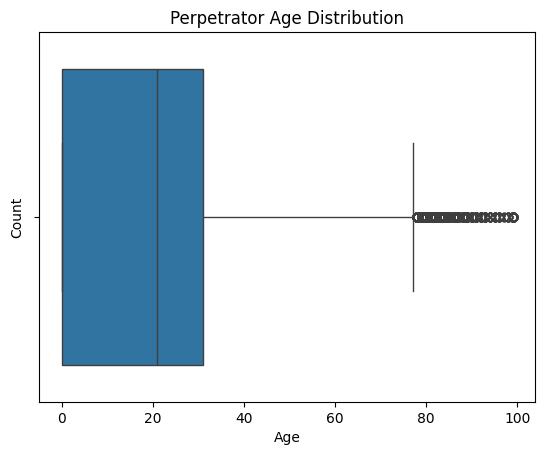

median age of offender: 21.0


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert 'Perpetrator Age' to numeric, coercing errors to NaN
dataset['Perpetrator Age'] = pd.to_numeric(dataset['Perpetrator Age'], errors='coerce')
# Convert 'Victim Age' to numeric, coercing errors to NaN
dataset['Victim Age'] = pd.to_numeric(dataset['Victim Age'], errors='coerce')

# Replace age values of 998 or higher with NaN, as they likely represent missing or invalid data
dataset.loc[dataset['Victim Age'] >= 998, 'Victim Age'] = np.nan
dataset.loc[dataset['Perpetrator Age'] >= 998, 'Perpetrator Age'] = np.nan

sns.boxplot(x=dataset['Perpetrator Age'])
plt.title('Perpetrator Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print("median age of offender:", dataset['Perpetrator Age'].median() )

The boxplot tells us that 50% of the offenders are younger than
 the ages of 20-22

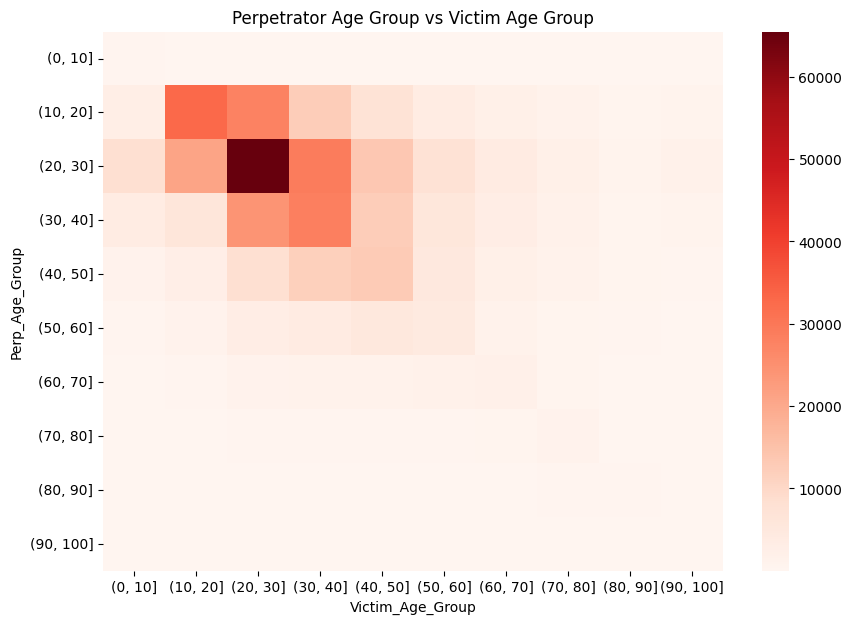

In [108]:
bins = [0,10,20,30,40,50,60,70,80,90,100]

df['Victim_Age_Group'] = pd.cut(df['Victim Age'], bins)
df['Perp_Age_Group'] = pd.cut(df['Perpetrator Age'], bins)

table = pd.crosstab(
    df['Perp_Age_Group'],
    df['Victim_Age_Group']
)
plt.figure(figsize=(10,7))

sns.heatmap(table, cmap='Reds')

plt.title("Perpetrator Age Group vs Victim Age Group")

plt.show()

HEATMAP


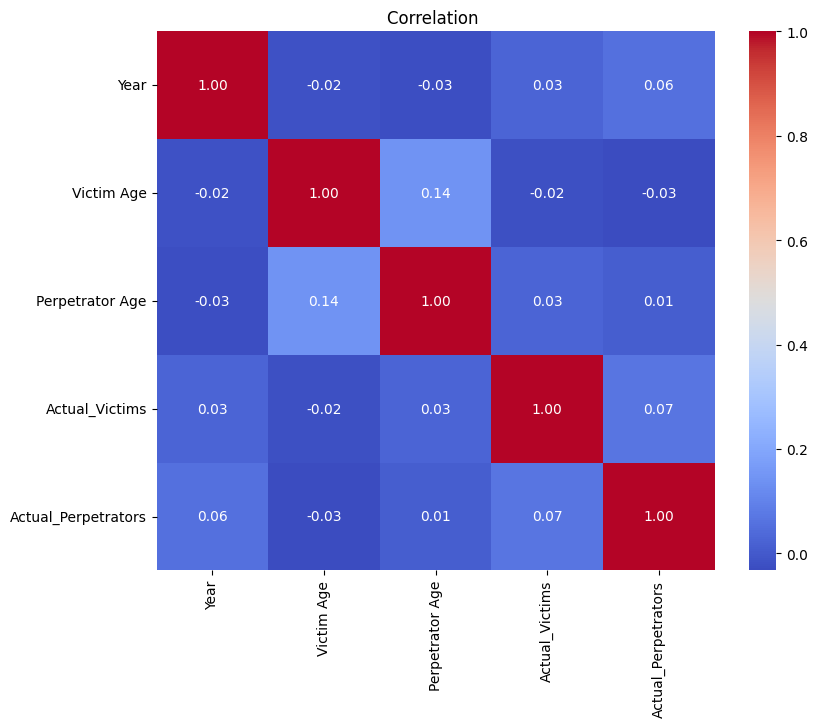

In [111]:
heatmap_cols = [
    'Year',
    'Victim Age',
    'Perpetrator Age',
    'Actual_Victims',
    'Actual_Perpetrators',


]

corr_matrix = dataset[heatmap_cols].corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation ")
plt.show()


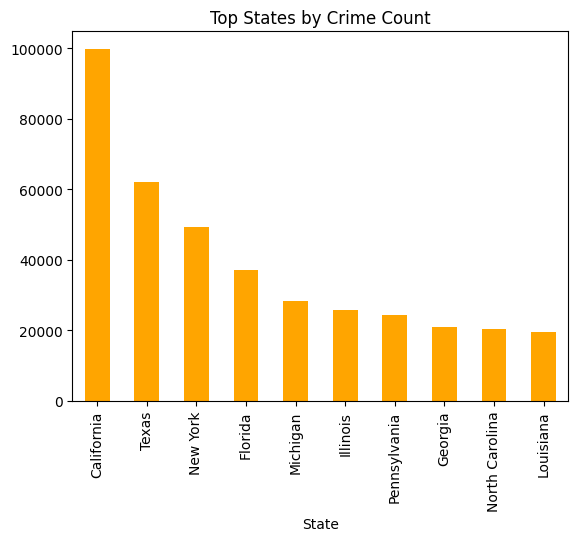

In [113]:
dataset['State'].value_counts().head(10).plot(kind='bar',color ='orange')
plt.title("Top States by Crime Count")
plt.show()


<Axes: xlabel='Weapon'>

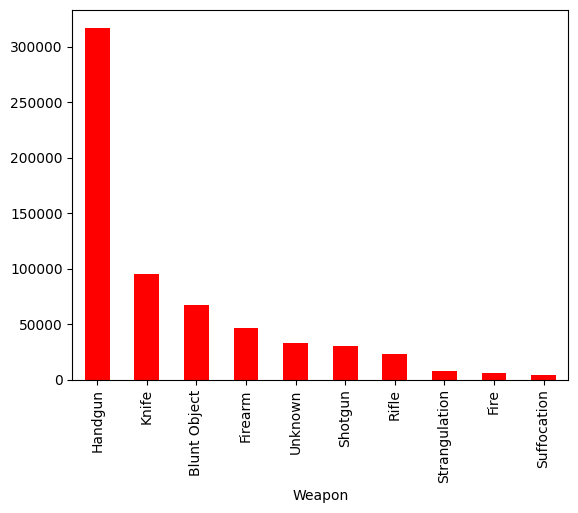

In [115]:
dataset['Weapon'].value_counts().head(10).plot(kind='bar', color ='red')


Text(0.5, 1.0, 'Crime rate over the years')

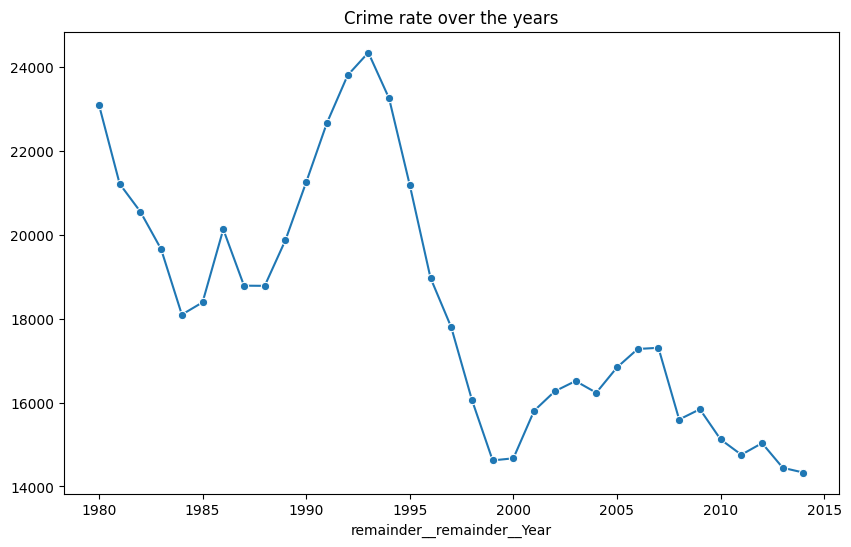

In [ ]:
#crime over the years plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

count_murder = dataset['remainder__remainder__Year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x=count_murder.index, y=count_murder.values, marker='o')
plt.title('Crime rate over the years')




In [ ]:
print(count_murder)

remainder__remainder__Year
1980    23092
1981    21208
1982    20544
1983    19653
1984    18093
1985    18386
1986    20125
1987    18783
1988    18779
1989    19868
1990    21246
1991    22657
1992    23793
1993    24335
1994    23246
1995    21179
1996    18969
1997    17794
1998    16061
1999    14621
2000    14671
2001    15803
2002    16268
2003    16512
2004    16233
2005    16836
2006    17275
2007    17303
2008    15595
2009    15840
2010    15121
2011    14756
2012    15033
2013    14445
2014    14331
Name: count, dtype: int64
